In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import os.path as op
from dipy.core.gradients import gradient_table

import dipy.reconst.fwdti as fwdti
from pathlib import Path
import subprocess
import fsl

ModuleNotFoundError: No module named 'gtab'

In [46]:
data = "/Users/ecd25/Desktop/PhD_Diss/Glioma/OA/Glioma/dif/sub-14/data_1600.nii.gz"
data_img = nib.load(
    "/Users/ecd25/Desktop/PhD_Diss/Glioma/OA/Glioma/dif/sub-14/data.nii.gz"
)
mask = "/Users/ecd25/Desktop/PhD_Diss/Glioma/OA/Glioma/dif/sub-14/nodif_brain_mask.nii.gz"
mask_img = nib.load(
    "/Users/ecd25/Desktop/PhD_Diss/Glioma/OA/Glioma/dif/sub-14/nodif_brain_mask.nii.gz"
)
bvecs = "/Users/ecd25/Desktop/PhD_Diss/Glioma/OA/Glioma/dif/sub-14/bvecs"
bvals = "/Users/ecd25/Desktop/PhD_Diss/Glioma/OA/Glioma/dif/sub-14/bvals"

In [47]:
gtab = gradient_table(
    bvals=bvals,
    bvecs=bvecs,
    )

In [48]:
fwdtimodel = fwdti.FreeWaterTensorModel(gtab)

In [49]:
data = data_img.get_fdata()
mask = mask_img.get_fdata()

In [51]:
fwdtifit = fwdtimodel.fit(data, mask=mask)

/Users/ecd25/miniconda3/envs/numba-py311/lib/python3.11/site-packages/dipy/reconst/fwdti.py:701: RuntimeWarning: Number of calls to function has reached maxfev = 1800.
  this_tensor, status = opt.leastsq(
/Users/ecd25/miniconda3/envs/numba-py311/lib/python3.11/site-packages/dipy/reconst/fwdti.py:501: RuntimeWarning: overflow encountered in exp
  y = (1 - f) * np.exp(np.dot(design_matrix, tensor[:7])) + f * np.exp(


In [50]:
print(type(mask))
print(mask.shape)
print(type(data))
print(data.shape)

<class 'numpy.ndarray'>
(160, 160, 96)
<class 'numpy.ndarray'>
(160, 160, 96, 40)


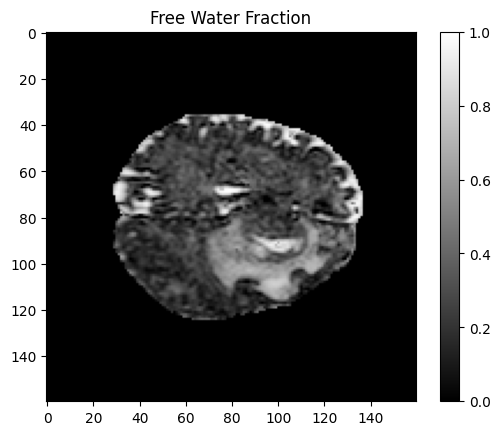

In [65]:
plt.imshow(fwdtifit.f[:, :, 60], cmap="gray", vmin=0, vmax=1)
plt.colorbar()
plt.title("Free Water Fraction")
plt.show()

In [69]:
import nibabel as nib
affine = data_img.affine

f_img = nib.Nifti1Image(fwdtifit.f, affine)
nib.save(f_img, "/Users/ecd25/Desktop/PhD_Diss/Glioma/OA/Glioma/dif/sub-14/fw_fraction.nii.gz")

In [70]:
!pip install dmri-amico

  Using cached babel-2.18.0-py3-none-any.whl.metadata (2.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 8.0 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 23.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 24.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 633.2/633.2 kB 17.1 MB/s  0:00:00
Using cached babel-2.18.0-py3-none-any.whl (10.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17/17 [dmri-amico]7 [dmri-amico]b]er]plehelp]


In [147]:
import amico

base = "/Users/ecd25/Desktop/PhD_Diss/Glioma/OA/Glioma/dif/sub-14"

ae = amico.Evaluation(base, "NODDI")

In [148]:
ae.set_config("DATA_path", base)
ae.set_config("OUTPUT_path", base + "/NODDI")
ae.set_config("ATOMS_path", base + "/kernels")

In [149]:
print(ae.get_config("ATOMS_path"))

/Users/ecd25/Desktop/PhD_Diss/Glioma/OA/Glioma/dif/sub-14/kernels


In [150]:
os.makedirs(base + "/kernels", exist_ok=True)
os.makedirs(base + "/NODDI", exist_ok=True)

In [151]:
ae.set_model("NODDI")

In [153]:
ae.load_data(
    dwi_filename="/Users/ecd25/Desktop/PhD_Diss/Glioma/OA/Glioma/dif/sub-14/data.nii.gz",
    scheme_filename="/Users/ecd25/Desktop/PhD_Diss/Glioma/OA/Glioma/dif/sub-14/bvals.scheme",
    mask_filename="/Users/ecd25/Desktop/PhD_Diss/Glioma/OA/Glioma/dif/sub-14/nodif_brain_mask.nii.gz",
    b0_thr=0
)


-> Loading data:
	* DWI signal
		- dim    = 160 x 160 x 96 x 40
		- pixdim = 1.500 x 1.500 x 1.500
	* Acquisition scheme
		- 40 samples, 7 shells
		- 1 @ b=0 , 16 @ b=3200.0 , 1 @ b=0.1 , 8 @ b=1600.0 , 1 @ b=0.0 , 8 @ b=800.0 , 1 @ b=0.0 , 4 @ b=400.0 
	* Binary mask
		- dim    = 160 x 160 x 96
		- pixdim = 1.500 x 1.500 x 1.500
		- voxels = 463749
   [ 0.7 seconds ]

-> Preprocessing:
	* Normalizing to b0... [ min=0.00,  mean=0.22, max=19.00 ]
	* Keeping all b0 volume(s)
   [ 0.5 seconds ]


In [154]:
ae.generate_kernels(regenerate=True)


-> Creating LUT for "NODDI" model:
   [ 2.9 seconds ]                                                                                                                                   


In [155]:
ae.load_kernels()


-> Resampling LUT for subject "NODDI":
   [ 0.3 seconds ]                                                                                                                                   


In [156]:
ae.fit()


-> Estimating principal directions (OLS):
   [ 00h 00m 00s ]                                                                                                                                   

-> Fitting 'NODDI' model to 463749 voxels (using 12 threads):
   [ 00h 00m 07s ]                                                                                                                                   


In [157]:
ae.save_results()


-> Saving output to "/Users/ecd25/Desktop/PhD_Diss/Glioma/OA/Glioma/dif/sub-14/NODDI/*":
	- configuration  [OK]
	- fit_dir.nii.gz  [OK]
	- fit_NDI.nii.gz  [OK]
	- fit_ODI.nii.gz  [OK]
	- fit_FWF.nii.gz  [OK]
   [ DONE ]


In [158]:
print(ae.get_config("ATOMS_path"))
print(ae.get_config("DATA_path"))
print(ae.get_config("OUTPUT_path"))

/Users/ecd25/Desktop/PhD_Diss/Glioma/OA/Glioma/dif/sub-14/kernels/NODDI
/Users/ecd25/Desktop/PhD_Diss/Glioma/OA/Glioma/dif/sub-14
/Users/ecd25/Desktop/PhD_Diss/Glioma/OA/Glioma/dif/sub-14/NODDI
